In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import joblib

In [2]:
def simulate_profit(Mrash, rash, Mryn, ryn, dol_distribution="uniform", dol_params=(0.1, 0.5), Np=1000, Ka=1.28):
    rash_values = np.random.normal(loc=Mrash, scale=rash, size=Np)
    ryn_values = np.random.normal(loc=Mryn, scale=ryn, size=Np)

    if dol_distribution == "uniform":
        dol_values = np.random.uniform(low=dol_params[0], high=dol_params[1], size=Np)
    elif dol_distribution == "normal":
        mu, sigma = dol_params
        dol_values = np.random.normal(loc=mu, scale=sigma, size=Np)
        dol_values = np.clip(dol_values, 0, 1)
    else:
        raise ValueError("Unsupported distribution type for Dol")

    profit_values = ryn_values * dol_values - rash_values

    Mprof = np.mean(profit_values)
    std_prof = np.std(profit_values)
    Gprof = Mprof - Ka * std_prof

    return {
        "profits": profit_values,
        "Mprof": Mprof,
        "std_prof": std_prof,
        "Gprof": Gprof
    }


In [3]:
def generate_training_dataset(num_samples=10000, Np=1000, Ka=1.28, seed=42):
    np.random.seed(seed)
    records = []
    for _ in range(num_samples):
        Mrash = np.random.uniform(30000, 70000)
        rash = np.random.uniform(5000, 15000)
        Mryn = np.random.uniform(100000, 300000)
        ryn = np.random.uniform(10000, 50000)
        dol_low = np.random.uniform(0.05, 0.3)
        dol_high = np.random.uniform(dol_low + 0.05, min(dol_low + 0.5, 1.0))

        result = simulate_profit(Mrash, rash, Mryn, ryn, "uniform", (dol_low, dol_high), Np, Ka)

        records.append({
            "Mrash": Mrash,
            "rash": rash,
            "Mryn": Mryn,
            "ryn": ryn,
            "dol_low": dol_low,
            "dol_high": dol_high,
            "Gprof": result["Gprof"]
        })

    df = pd.DataFrame(records)
    df.to_csv("training_data.csv", index=False)
    print("Обучающая выборка сохранена в training_data.csv")

    return df

In [4]:
generate_training_dataset(num_samples=10000)

Обучающая выборка сохранена в training_data.csv


,Mrash,rash,Mryn,ryn,dol_low,dol_high,Gprof
0,44981.604754,14507.143064,246398.788362,33946.339368,0.089005,0.209202,-30655.815775
1,33290.892971,9595.840572,161292.693609,42895.248447,0.064245,0.302618,-26266.965977
2,44268.926772,10924.829939,267114.341018,11746.437149,0.109158,0.559545,-832.612087
3,63526.368056,10252.022002,141665.389372,30987.536484,0.188771,0.572877,-38796.673584
4,36817.328075,8524.627844,254834.300005,11216.892576,0.218238,0.635617,33880.502833
...,...,...,...,...,...,...,...
9995,34449.913569,5806.230609,289611.486936,37220.141343,0.217934,0.474502,32739.223726
9996,62815.367779,8495.367541,105444.032824,43011.187691,0.292349,0.752347,-44553.095825
9997,56202.287210,12492.804591,120220.791469,49616.375904,0.067872,0.253848,-57807.062273
9998,45529.166477,6675.774262,249756.945595,37540.387854,0.252025,0.719916,22752.174014


In [30]:
def plot_gprof_distribution(df):
    plt.figure(figsize=(10, 6))
    plt.hist(df["Gprof"], bins=50, color="skyblue", edgecolor="black")
    plt.title("Распределение Gprof")
    plt.xlabel("Gprof")
    plt.ylabel("Частота")
    plt.grid(True)
    plt.show()

def plot_correlation_matrix(df):
    plt.figure(figsize=(10, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Матрица корреляций")
    plt.show()

def plot_scatter_mryn_vs_gprof(df):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="Mryn", y="Gprof", s=30, alpha=0.5)
    plt.title("Связь между Mryn и Gprof")
    plt.xlabel("Mryn")
    plt.ylabel("Gprof")
    plt.grid(True)
    plt.show()

def plot_scatter_mrash_vs_gprof(df):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="Mrash", y="Gprof", s=30, alpha=0.5)
    plt.title("Связь между Mrash и Gprof")
    plt.xlabel("Mrash")
    plt.ylabel("Gprof")
    plt.grid(True)
    plt.show()

def plot_standardization_comparison(df, feature):
    scaler = StandardScaler()
    standardized = scaler.fit_transform(df[[feature]])

    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    sns.kdeplot(df[feature], ax=axs[0], fill=True, color="skyblue", linewidth=2)
    axs[0].set_title(f"Исходное распределение '{feature}'")
    axs[0].set_xlabel(feature)
    axs[0].set_ylabel("Плотность")
    axs[0].set_ylim(0, 0.35)
    axs[0].grid(True)

    sns.kdeplot(standardized[:, 0], ax=axs[1], fill=True, color="orange", linewidth=2)
    axs[1].set_title(f"Стандартизованное распределение '{feature}'")
    axs[1].set_xlabel(feature)
    axs[1].set_ylim(0, 0.35)
    axs[1].grid(True)

    plt.suptitle(f"Сравнение распределений признака '{feature}' до и после стандартизации")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def train_model(data_path="training_data.csv"):
    df = pd.read_csv(data_path)
    X = df[["Mrash", "rash", "Mryn", "ryn", "dol_low", "dol_high"]]
    y = df["Gprof"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Среднеквадратичная ошибка модели: {mse:.2f}")

    joblib.dump((model, scaler), "gprof_predictor.pkl")
    print("Модель и скейлер сохранены в gprof_predictor.pkl")


def predict_gprof_with_model(Mrash, rash, Mryn, ryn, dol_low, dol_high):
    model, scaler = joblib.load("gprof_predictor.pkl")
    X = np.array([[Mrash, rash, Mryn, ryn, dol_low, dol_high]])
    X_scaled = scaler.transform(X)
    return model.predict(X_scaled)[0]

df = pd.read_csv("training_data.csv")

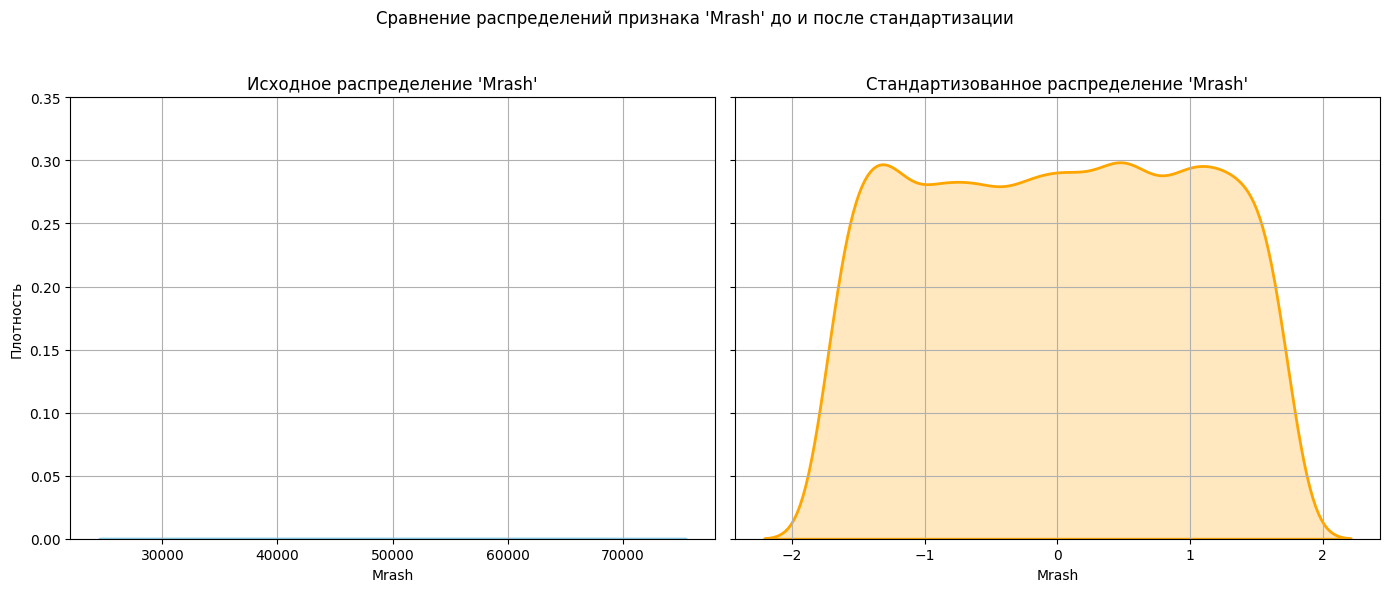

In [34]:
plot_standardization_comparison(df, "Mrash")

In [33]:
train_model()

Среднеквадратичная ошибка модели: 1197130.18
Модель и скейлер сохранены в gprof_predictor.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


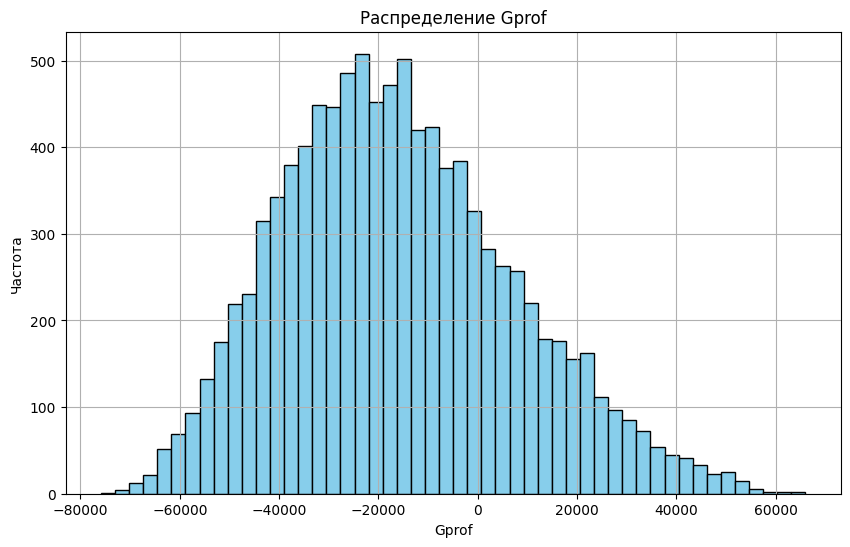

In [32]:
plot_gprof_distribution(df)

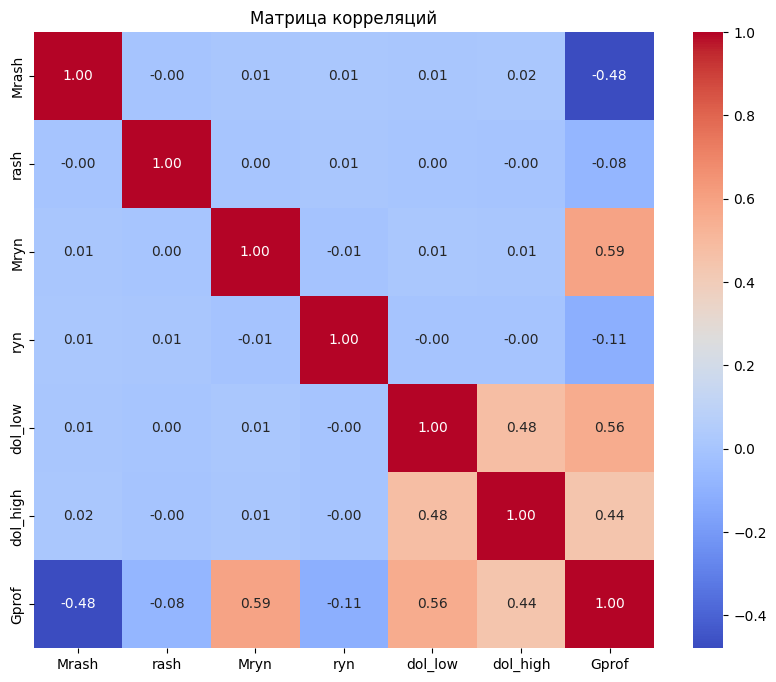

In [35]:
plot_correlation_matrix(df)

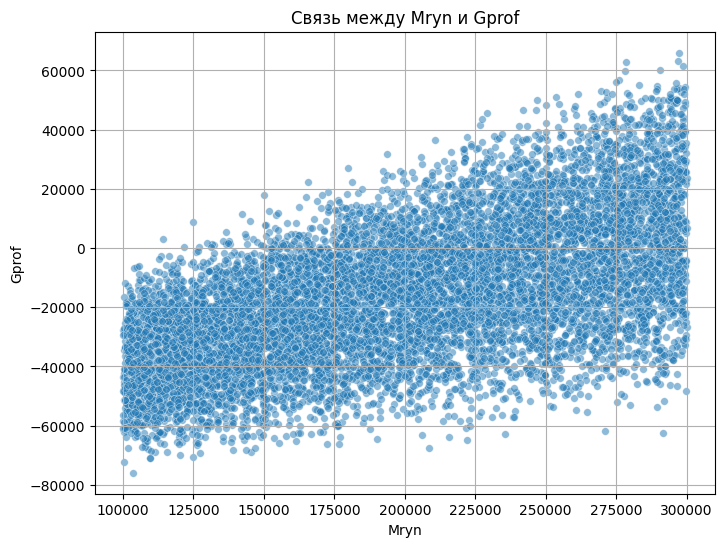

In [36]:
plot_scatter_mryn_vs_gprof(df)

In [25]:
def plot_joint_with_gprof(df, feature):
    g = sns.jointplot(
        data=df,
        x=feature,
        y="Gprof",
        kind="reg",
        height=6,
        scatter_kws={"s": 1, "alpha": 0.5}
    )
    g.fig.suptitle(f"Зависимость Gprof от {feature}", fontsize=14)
    g.fig.tight_layout()
    g.fig.subplots_adjust(top=0.95)

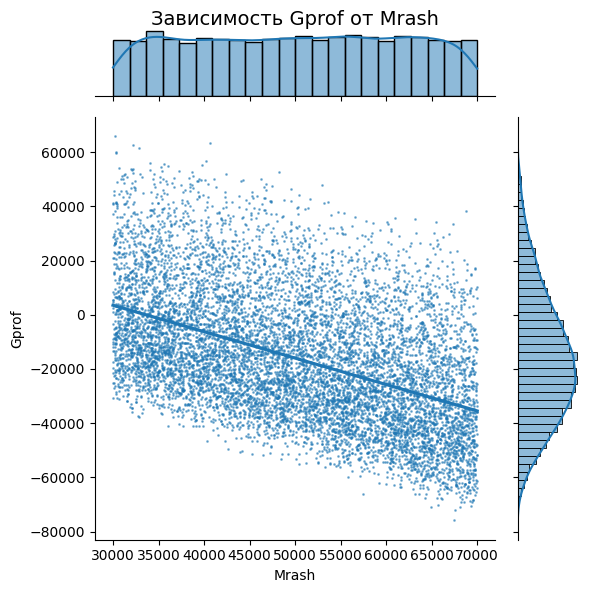

In [26]:
plot_joint_with_gprof(df, "Mrash")

In [17]:
model, scaler = joblib.load("gprof_predictor.pkl")

X = df[["Mrash", "rash", "Mryn", "ryn", "dol_low", "dol_high"]]
y = df["Gprof"]

X_scaled = scaler.transform(X)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.3f}")

Root Mean Squared Error (RMSE): 1102.55
R2 Score: 0.998
